# Vehicle Routing — the Capacitated Vehicle Routing Problem (CVRP) in LangGOAP

A Tier 2 tutorial that translates a 2-vehicle / 4-customer subset of
the Capacitated Vehicle Routing Problem (CVRP)
(`cvrp-32customers`) into a LangGOAP A\* + CSP pipeline.

## The problem

A fleet of vehicles must deliver goods to every customer and return
to the depot such that:

- **No vehicle exceeds its carrying capacity** — hard per-vehicle
  constraints on the ``load_<v>`` resource, enforced by the CSP.
- **Total travel distance is minimized** — driven by A\* cost.
- **Vehicles execute in parallel** — independent routes become
  independent dependency chains that CP-SAT schedules concurrently,
  yielding a two-lane Gantt chart.

## LangGOAP modelling

| GOAP concept              | Vehicle routing interpretation                      |
|---------------------------|-----------------------------------------------------|
| `ActionSpec`              | `move_<vehicle>_<from>_to_<to>`                     |
| precondition              | `<vehicle>_at_<from>=True`                          |
| effects                   | move forward; on arrival, `visited_<customer>=True` |
| `cost`                    | Manhattan distance between locations                |
| `duration`                | travel time + service time at destination           |
| `resources.load_<v>`      | customer demand aggregated per vehicle              |
| goal `constraints` (hard) | per-vehicle capacity caps                           |
| goal `objectives`         | minimize `distance_<v>` per vehicle                 |

## Scope caveats

- **Customers are pre-assigned** to vehicles in this fixture.  The
  pre-assignment would normally come from an outer clustering step;
  LangGOAP optimizes the *order* within each vehicle's route.
- **No time windows.**  LangGOAP's CSP scheduler minimizes
  precedence-constrained makespan; time windows from the CVRPTW
  variant are out of scope for v0.1.0.
- **Manhattan distances on a symbolic grid** keep the tutorial
  compact.  The provenance header in the data module documents how
  this maps to the reference problem instance.

In [1]:
import logging

# The CSP pipeline emits a single 'All alternative plans infeasible'
# warning when a tight-budget scenario can't produce a feasible plan
# by blacklisting individual actions.  We demonstrate that case
# deliberately in the infeasibility cell.
logging.getLogger("langgoap").setLevel(logging.ERROR)

from tutorial_examples.data.vehicle_routing_instance import (
    CUSTOMERS,
    VEHICLES,
    distance,
)
from tutorial_examples.vehicle_routing import (
    vehicle_routing_actions,
    vehicle_routing_goal,
    vehicle_routing_start,
)

from langgoap import ConstraintSpec, CSPStatus, GoalSpec, GoapGraph
from langgoap.planner.pipeline import plan as pipeline_plan
from langgoap.state import PlanningState

print("Vehicles:")
for v in VEHICLES:
    print(f"  {v.name:4s} capacity={v.capacity}")

print("\nCustomers:")
for c in CUSTOMERS:
    print(
        f"  {c.name:4s} demand={c.demand:2d} service={c.service_minutes:2d} min"
        f"  -> {c.assigned_to}"
    )

print("\nDistance matrix (Manhattan):")
locs = ["depot"] + [c.name for c in CUSTOMERS]
header = "       " + "".join(f"{l:>6s}" for l in locs)
print(header)
for a in locs:
    row = f"  {a:5s}" + "".join(f"{distance(a, b):>6d}" for b in locs)
    print(row)

Vehicles:
  v1   capacity=50
  v2   capacity=20

Customers:
  c2   demand=26 service=15 min  -> v1
  c3   demand=17 service=12 min  -> v1
  c4   demand= 6 service= 8 min  -> v1
  c5   demand=15 service=10 min  -> v2

Distance matrix (Manhattan):
        depot    c2    c3    c4    c5
  depot     0    10    20    20    25
  c2       10     0    10    20    15
  c3       20    10     0    10    15
  c4       20    20    10     0    25
  c5       25    15    15    25     0


## 1. Action catalog

Each vehicle gets one `ActionSpec` per ordered pair of legal
locations (its depot and its pre-assigned customers).  Vehicle
`v1` has 4 locations (depot + 3 customers) → 4×3 = 12 moves;
vehicle `v2` has 2 locations → 2 moves.  Total: 14 actions.

In [2]:
actions = vehicle_routing_actions()
print(f"Total actions: {len(actions)}\n")

v1_moves = [a for a in actions if a.name.startswith("move_v1_")]
print(f"Vehicle v1 ({len(v1_moves)} moves):")
for a in v1_moves:
    segment = a.name.removeprefix("move_v1_")
    dur = int(a.duration.total_seconds() / 60) if a.duration else 0
    print(f"  {segment:18s} cost={a.cost:4.0f}  duration={dur:3d} min")

v2_moves = [a for a in actions if a.name.startswith("move_v2_")]
print(f"\nVehicle v2 ({len(v2_moves)} moves):")
for a in v2_moves:
    segment = a.name.removeprefix("move_v2_")
    dur = int(a.duration.total_seconds() / 60) if a.duration else 0
    print(f"  {segment:18s} cost={a.cost:4.0f}  duration={dur:3d} min")

Total actions: 14

Vehicle v1 (12 moves):
  depot_to_c2        cost=  10  duration= 25 min
  depot_to_c3        cost=  20  duration= 32 min
  depot_to_c4        cost=  20  duration= 28 min
  c2_to_depot        cost=  10  duration= 10 min
  c2_to_c3           cost=  10  duration= 22 min
  c2_to_c4           cost=  20  duration= 28 min
  c3_to_depot        cost=  20  duration= 20 min
  c3_to_c2           cost=  10  duration= 25 min
  c3_to_c4           cost=  10  duration= 18 min
  c4_to_depot        cost=  20  duration= 20 min
  c4_to_c2           cost=  20  duration= 35 min
  c4_to_c3           cost=  10  duration= 22 min

Vehicle v2 (2 moves):
  depot_to_c5        cost=  25  duration= 35 min
  c5_to_depot        cost=  25  duration= 25 min


### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

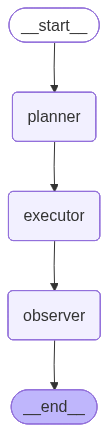

In [3]:
from IPython.display import Image, display

graph = GoapGraph(actions=actions)
display(Image(graph.compile().get_graph().draw_mermaid_png()))

## 2. Run the A\* → CSP pipeline

A\* searches the combined state space (per-vehicle positions +
per-customer visited flags) and returns the lowest-cost sequence
that satisfies the goal.  Because the two vehicles share no state
variables, A\* interleaves the plan freely — the CSP phase then
recovers the true parallelism from the dependency graph.

In [4]:
plan_obj = pipeline_plan(
    PlanningState.from_dict(vehicle_routing_start()),
    vehicle_routing_goal(),
    actions,
)
assert plan_obj is not None

print(f"A* total cost:   {plan_obj.total_cost:.0f}")
print(f"CSP status:      {plan_obj.metadata.csp.status.value}")
print(f"Plan steps:")
for step in plan_obj.actions:
    print(f"  {step.name}")

A* total cost:   100
CSP status:      feasible
Plan steps:
  move_v1_depot_to_c2
  move_v1_c2_to_c3
  move_v1_c3_to_c4
  move_v1_c4_to_depot
  move_v2_depot_to_c5
  move_v2_c5_to_depot


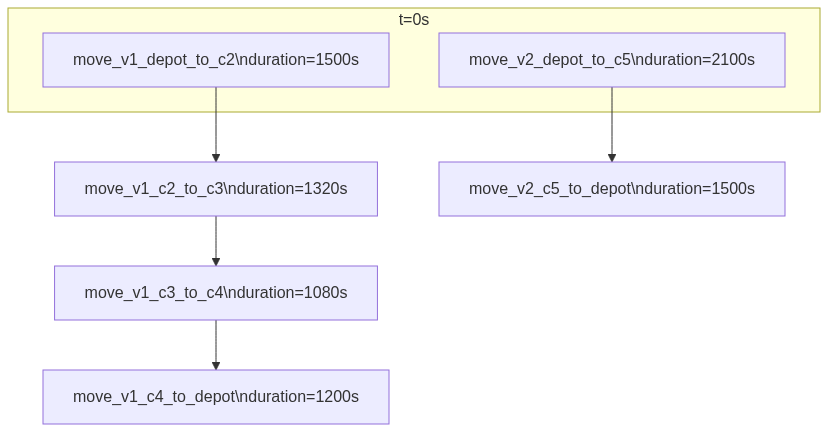

In [5]:
from langchain_core.runnables.graph_mermaid import draw_mermaid_png as _draw_png
from langgoap.viz.mermaid import render_mermaid

display(Image(_draw_png(render_mermaid(plan_obj))))

## 3. Parallel schedule from the CSP

The CSP scheduler calls `build_dependency_graph()` which scans
effect→precondition chains.  For this problem that yields one
chain per vehicle (because each move consumes `<v>_at_<from>`
produced by the previous move) and **no cross-vehicle edges**.
CP-SAT schedules both chains concurrently and minimizes the
makespan.

> **Note on idle time.**  CP-SAT minimizes makespan only, not sum
> of completion times.  Once the longer route's end time fixes the
> makespan, the solver is free to place the shorter vehicle's
> moves anywhere in `[0, makespan]` as long as precedence holds.
> You may therefore see the shorter route sit idle between its
> moves — that is a legal schedule, not a bug.

In [6]:
csp = plan_obj.metadata.csp

print(f"Makespan: {csp.makespan}\n")
print("Schedule:")
for entry in csp.schedule:
    start_min = int(entry.start.total_seconds() / 60)
    end_min = int(entry.end.total_seconds() / 60)
    segment = entry.action_name.split("_", 2)[-1]  # drop the "move_" prefix
    print(f"  [{start_min:3d} -> {end_min:3d} min]  {segment}")

Makespan: 1:25:00

Schedule:
  [  0 ->  25 min]  depot_to_c2
  [ 25 ->  47 min]  c2_to_c3
  [ 47 ->  65 min]  c3_to_c4
  [ 65 ->  85 min]  c4_to_depot
  [  0 ->  35 min]  depot_to_c5
  [ 60 ->  85 min]  c5_to_depot


## 4. ASCII Gantt — two vehicles running in parallel

A one-row-per-vehicle Gantt makes the concurrency obvious.
Each character is 5 minutes of wall time.

In [7]:
TICK_MIN = 5       # one tick = 5 wall-clock minutes
CHARS_PER_TICK = 2  # each tick rendered as 2 chars wide

makespan_min = int(csp.makespan.total_seconds() / 60)
tick_count = makespan_min // TICK_MIN + 1
body_width = tick_count * CHARS_PER_TICK

# Group schedule entries by vehicle.
by_vehicle: dict[str, list] = {v.name: [] for v in VEHICLES}
for entry in csp.schedule:
    vehicle = entry.action_name.split("_")[1]  # move_v<m>_<from>_to_<to>
    by_vehicle[vehicle].append(entry)

# Build a label row with minute markers every 20 minutes.
label_cells = [" "] * body_width
for minute in range(0, makespan_min + 1, 20):
    col = (minute // TICK_MIN) * CHARS_PER_TICK
    for i, ch in enumerate(str(minute)):
        if col + i < body_width:
            label_cells[col + i] = ch

header = f"{'vehicle':8s}| "
print(header + "".join(label_cells) + "   (minutes)")
print(header + "-" * body_width)

for v in VEHICLES:
    row = ["."] * body_width
    for entry in by_vehicle[v.name]:
        start_tick = int(entry.start.total_seconds() / 60) // TICK_MIN
        dur_ticks = max(int(entry.duration.total_seconds() / 60) // TICK_MIN, 1)
        destination = entry.action_name.split("_to_")[1]
        label_char = destination[0] if destination != "depot" else "D"
        for tick in range(start_tick, min(start_tick + dur_ticks, tick_count)):
            for j in range(CHARS_PER_TICK):
                row[tick * CHARS_PER_TICK + j] = label_char
    print(f"  {v.name:5s} | " + "".join(row))

print("\nLegend: c# = at customer, D = returning to depot, . = idle")
print(f"Makespan: {makespan_min} minutes")

vehicle | 0       20      40      60      80     (minutes)
vehicle | ------------------------------------
  v1    | cccccccccccccccccccccccc..DDDDDDDD..
  v2    | cccccccccccccc..........DDDDDDDDDD..

Legend: c# = at customer, D = returning to depot, . = idle
Makespan: 85 minutes


## 5. Resource utilization

`CSPMetadata.resource_usage` reports the aggregate total for every
resource key touched by the plan.  Here we see each vehicle's
carried load alongside its total travel distance.

In [8]:
usage = {u.key: u.total for u in csp.resource_usage}

print("Per-vehicle utilization:")
for v in VEHICLES:
    load = usage.get(f"load_{v.name}", 0)
    dist = usage.get(f"distance_{v.name}", 0)
    pct = 100 * load / v.capacity if v.capacity else 0
    print(
        f"  {v.name:4s}  load={load:4.0f}/{v.capacity:<3d}  ({pct:4.0f}%)"
        f"   distance={dist:4.0f}"
    )

total_distance = sum(
    usage.get(f"distance_{v.name}", 0) for v in VEHICLES
)
print(f"\nFleet total distance: {total_distance:.0f}")

Per-vehicle utilization:
  v1    load=  49/50   (  98%)   distance=  50
  v2    load=  15/20   (  75%)   distance=  50

Fleet total distance: 100


## 6. Infeasibility: a capacity budget that can't be met

Vehicle `v1` must carry 26+17+6 = 49 units of demand to serve its
three assigned customers.  Tighten `v1`'s capacity to 40 and no
legal assignment exists — the CSP marks the plan INFEASIBLE.

The plan itself is still returned (CSP is advisory, not blocking)
so callers can inspect `plan.metadata.csp` and decide what to do
next: re-cluster, add a third vehicle, or surface the error to
the user.

In [9]:
tight_goal = GoalSpec(
    conditions={
        **{f"visited_{c.name}": True for c in CUSTOMERS},
        **{f"{v.name}_at_depot": True for v in VEHICLES},
    },
    constraints=(
        ConstraintSpec(key="load_v1", max=40.0, level="hard"),
        ConstraintSpec(key="load_v2", max=20.0, level="hard"),
    ),
)

tight_plan = pipeline_plan(
    PlanningState.from_dict(vehicle_routing_start()),
    tight_goal,
    actions,
)
assert tight_plan is not None

tight_usage = {u.key: u.total for u in tight_plan.metadata.csp.resource_usage}
print(f"v1 capacity budget:   40")
print(f"v1 required load:    {tight_usage['load_v1']:.0f}")
print(f"CSP status:          {tight_plan.metadata.csp.status.value}")

v1 capacity budget:   40
v1 required load:    49
CSP status:          infeasible


## 7. End-to-end via `GoapGraph`

The executor applies the effects of each move in order, and the
observer checks the goal conditions after every step.  When all
customers are visited and both vehicles are back at depot, the
graph terminates with `goal_achieved`.

In [10]:
result = GoapGraph(actions=actions).invoke(
    goal=vehicle_routing_goal(),
    world_state=vehicle_routing_start(),
)

print(f"Status:   {result['status']}")

ws = result["world_state"]
print(f"\nFinal world state (selected):")
for c in CUSTOMERS:
    print(f"  visited_{c.name}: {ws[f'visited_{c.name}']}")
for v in VEHICLES:
    print(f"  {v.name}_at_depot: {ws[f'{v.name}_at_depot']}")

Status:   goal_achieved

Final world state (selected):
  visited_c2: True
  visited_c3: True
  visited_c4: True
  visited_c5: True
  v1_at_depot: True
  v2_at_depot: True


## Summary

- **One LangGOAP problem, two planning phases.** A\* finds the
  cheapest route per vehicle in a shared state space; CSP
  validates capacity and schedules independent routes in parallel.
- **Per-vehicle dependency chains come for free.** Because each
  move both reads and writes `<vehicle>_at_<location>`, the default
  dependency graph produces exactly the chains CP-SAT needs — no
  custom wiring.
- **Hard capacity constraints never load an unfeasible truck.**
  Shrinking a vehicle's capacity below its true demand flips the
  CSP status to `INFEASIBLE` without breaking execution.
- **The Gantt is real.** Two vehicles run concurrently and the
  makespan equals the longer route's duration — the same output
  any constraint solver produces on richer CVRPTW instances.

Every scenario here is verified by
[`tests/integration/test_vehicle_routing.py`](../../tests/integration/test_vehicle_routing.py).